# **EDA Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [432]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/drive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

###### Setting up folders ######

You can now save your data files in: /content/drive/MyDrive/36106/assignment/AT3/data
/content/drive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [433]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [434]:
# <Student to fill this section>

### 0.d Import Packages

In [435]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt

---
## A. Project Description


In [436]:
# <Student to fill this section>
group_name = "36106-25AU-AT3-Group 18"
student_name = "Md Saifur Rahman"
student_id = "25528668"

In [437]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [438]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [439]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Data Understanding

### B.1   Load Dataset

In [440]:
# Do not modify this code
try:
  df = pd.read_csv(folder_path / "customer_satisfaction.csv")
except Exception as e:
  print(e)

### B.2 Explore Dataset

> You can add more cells in this section

In [441]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15774 entries, 0 to 15773
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   15774 non-null  int64 
 1   customer_id  15774 non-null  object
 2   nps          15774 non-null  int64 
 3   cltv         15774 non-null  int64 
 4   reason       4189 non-null   object
dtypes: int64(3), object(2)
memory usage: 616.3+ KB


In [442]:
df.describe()

,Unnamed: 0,nps,cltv
count,15774.000000,15774.000000,15774.000000
mean,7886.500000,3.249525,4386.955750
std,4553.705908,1.201393,1191.571121
min,0.000000,1.000000,2003.000000
25%,3943.250000,3.000000,3424.000000
50%,7886.500000,3.000000,4539.000000
75%,11829.750000,4.000000,5362.750000
max,15773.000000,5.000000,6500.000000


In [443]:
df.head(5)

,Unnamed: 0,customer_id,nps,cltv,reason
0,0,70f18737-5835-4639-be44-f1a8c6604490,4,2056,NaN
1,1,206e8726-2743-4739-8f2f-758e30256314,3,2916,NaN
2,2,40da1c87-0650-4378-b8d7-0a49cb21085c,4,5248,NaN
3,3,4e28bb69-cee2-4fdf-8831-28935bb5e9b6,3,4607,NaN
4,4,39c9339b-c22b-4bf2-8c73-deb7b6e02de1,4,3030,NaN


In [444]:
df.shape

(15774, 5)

In [445]:
df.isnull().sum()

,0
Unnamed: 0,0
customer_id,0
nps,0
cltv,0
reason,11585


In [446]:
df['reason'].value_counts()

,count
reason,
Competitor made better offer,687
Competitor had better devices,667
Attitude of support person,516
Don't know,306
Competitor offered more data,267
Attitude of service provider,220
Product dissatisfaction,208
Competitor offered higher download speeds,207
Network reliability,177


In [447]:
df['customer_id'].value_counts()

,count
customer_id,
59eecf54-cfc1-4dd4-ac06-4b2a0831ca00,7
bc42c41f-0d04-412e-afa8-d9a6f2820997,7
65a1d9b8-f777-4d36-a73a-37d5e1afff5e,7
548a295b-46b7-4514-aabd-0a45f56af8c9,7
500e96e1-7080-45a7-b361-b1eb63392e85,7
...,...
96cbcf56-6d5c-4f4e-a54b-df8c2880596b,1
c1e22f41-7fa8-48f7-9ce4-748f8377ff87,1
25b6d669-fae7-47ae-b3e8-54c9a23a580c,1


In [448]:
# <Student to fill this section>
dataset_insights = """
The customer_satisfaction.csv dataset contains 15,774 records and five columns. Among these, three are numerical (Unnamed: 0, nps, and cltv) and two are categorical (customer_id and reason). The Unnamed: 0 column appears to be an auto-generated index and provides no meaningful information—it can be safely dropped during the preprocessing stage.

A significant observation is the presence of missing values in the reason column, which contains only 4,189 non-null entries. This means approximately 73.4% of the values in this column are missing, suggesting that churn reasons were collected only from a subset of customers, likely those who have already left the company. This column, though sparse, can still provide important signals if handled properly.

The nps (Net Promoter Score) ranges from 1 to 5 with a mean value of approximately 3.25, indicating that most customers rated the service as neutral to moderately positive. This variable can be binned to categorize customers into unsatisfied (1–2), neutral (3), and satisfied (4–5), making it a strong candidate for a classification target.

The cltv (Customer Lifetime Value) column ranges from 2003 to 6500 with an average value of approximately 4387. Its distribution appears roughly normal, suggesting it can be used as a reliable numerical predictor without major transformation.

Regarding the reason column, there are 20 unique churn reasons provided by the respondents. The most common reasons include "Competitor made better offer" (687), "Competitor had better devices" (667), and "Attitude of support person" (516). These churn categories provide qualitative insight into dissatisfaction factors and can be useful for grouping similar cases.

Lastly, while customer_id should ideally be unique, it appears that several IDs occur multiple times (up to 7 times each). There are only 7,043 unique customer IDs, which is significantly less than the total number of rows. This indicates either repeated satisfaction surveys for the same customer or data duplication—an important point that must be addressed during the data cleaning phase.

Overall, this dataset provides valuable information for understanding customer satisfaction patterns and can support classification tasks. However, careful handling of missing data and repeated entries will be essential in building a robust predictive model.
"""


In [449]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.3 Explore Feature of Interest 1

> You can add more cells in this section

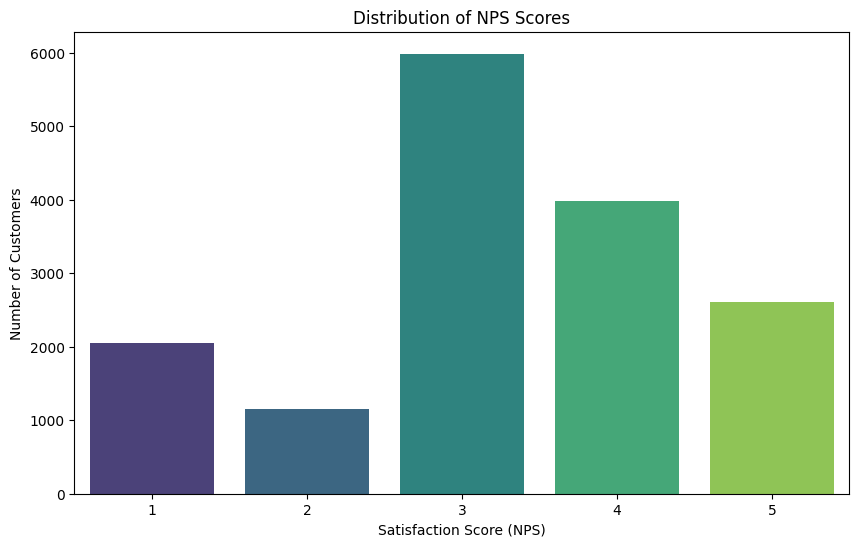

In [450]:
# prompt: Distribution of NPS scores
# xlabel('Satisfaction Score (NPS)')
# ylabel('Number of Customers')
# also add color palette

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='nps', palette='viridis')
plt.xlabel('Satisfaction Score (NPS)')
plt.ylabel('Number of Customers')
plt.title('Distribution of NPS Scores')
plt.show()

In [451]:
# Get numeric counts of each NPS score
nps_counts = df['nps'].value_counts().sort_index()

# Display as a DataFrame for readability
nps_counts_df = nps_counts.reset_index()
nps_counts_df.columns = ['NPS Score', 'Number of Customers']
display(nps_counts_df)

,NPS Score,Number of Customers
0,1,2047
1,2,1159
2,3,5985
3,4,3977
4,5,2606


In [452]:
feature1_insights = """
Feature: Net Promoter Score (NPS)

The Net Promoter Score (NPS) measures customer satisfaction on a scale from 1 (Very Unsatisfied) to 5 (Very Satisfied). In this dataset, the NPS distribution highlights clear trends in customer sentiment.

The majority of customers fall into the neutral and moderately satisfied categories. A total of 5,985 customers (the largest group) gave a score of 3, followed by 3,977 customers who gave a score of 4. Additionally, 2,606 customers expressed high satisfaction with a score of 5. On the lower end, 2,047 customers rated their experience as very unsatisfactory (score of 1), while 1,159 customers gave a slightly better but still negative score of 2.

This distribution suggests that while a significant portion of customers is content or neutral, there remains a sizable group of dissatisfied users. From a business standpoint, grouping NPS into satisfaction categories—such as unsatisfied (1–2), neutral (3), and satisfied (4–5)—can support churn prediction models and help prioritize customer retention strategies.
"""


In [453]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### B.4 Explore Feature of Interest 2

> You can add more cells in this section

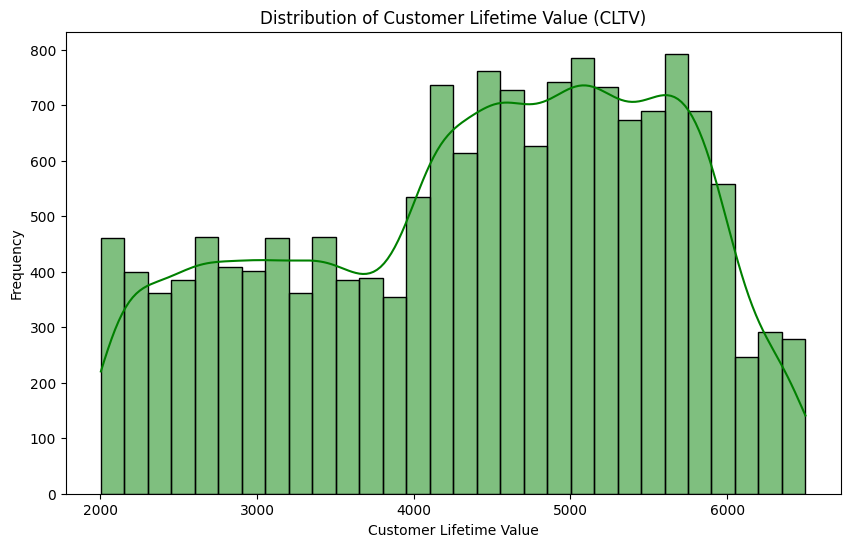

In [454]:
# prompt: title 'Distribution of Customer Lifetime Value (CLTV)'
# xlabel('Customer Lifetime Value')
# ylabel('Frequency')
# also add color to the graph

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(df['cltv'], bins=30, kde=True, color='green')
plt.title('Distribution of Customer Lifetime Value (CLTV)')
plt.xlabel('Customer Lifetime Value')
plt.ylabel('Frequency')
plt.show()


In [455]:
# Compute bin edges and frequencies
cltv_counts, cltv_bins = np.histogram(df['cltv'], bins=30)

# Convert to readable DataFrame
cltv_bin_labels = [f"{int(cltv_bins[i])} – {int(cltv_bins[i+1])}" for i in range(len(cltv_bins)-1)]
cltv_hist_df = pd.DataFrame({'CLTV Range': cltv_bin_labels, 'Frequency': cltv_counts})

# Display the table
display(cltv_hist_df)

,CLTV Range,Frequency
0,2003 – 2152,460
1,2152 – 2302,400
2,2302 – 2452,362
3,2452 – 2602,386
4,2602 – 2752,463
5,2752 – 2902,409
6,2902 – 3052,402
7,3052 – 3202,460
8,3202 – 3352,361
9,3352 – 3502,462


In [456]:
# <Student to fill this section>
feature_2_insights = """
Feature: Customer Lifetime Value (CLTV)

Customer Lifetime Value (CLTV) is a key financial metric representing the total revenue a business expects from a customer throughout their relationship. In this dataset, CLTV ranges from 2003 to 6500. The distribution of CLTV across 30 bins reveals valuable insights into the customer base.

The lowest CLTV range (2003–2152) includes 460 customers, while the highest range (6350–6500) has 279 customers. The frequency increases notably in the mid-to-high value ranges, with the peak observed in the 5600–5750 range (793 customers). Other high-density bands include 5001–5150 (785 customers), 4551–4701 (728 customers), and 5150–5300 (733 customers).

This skew toward the higher end suggests that the company has a significant portion of high-value customers. From a business perspective, this provides a strong opportunity to target retention campaigns and satisfaction efforts toward customers in these top CLTV segments. Additionally, CLTV can be binned into low, medium, and high categories for feature engineering, or used as a continuous input in prediction models to assess satisfaction or churn risk.
"""


In [457]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.5 Explore Feature of Interest n

> You can add more cells in this section


Count of each reason category (excluding missing):
reason
Competitor made better offer                 687
Competitor had better devices                667
Attitude of support person                   516
Don't know                                   306
Competitor offered more data                 267
Attitude of service provider                 220
Product dissatisfaction                      208
Competitor offered higher download speeds    207
Network reliability                          177
Price too high                               169
Long distance charges                        142
Service dissatisfaction                      114
Moved                                         88
Poor expertise of online support              85
Extra data charges                            84
Limited range of services                     84
Lack of self-service on Website               67
Lack of affordable download/upload speed      63
Poor expertise of phone support               23
Deceased  

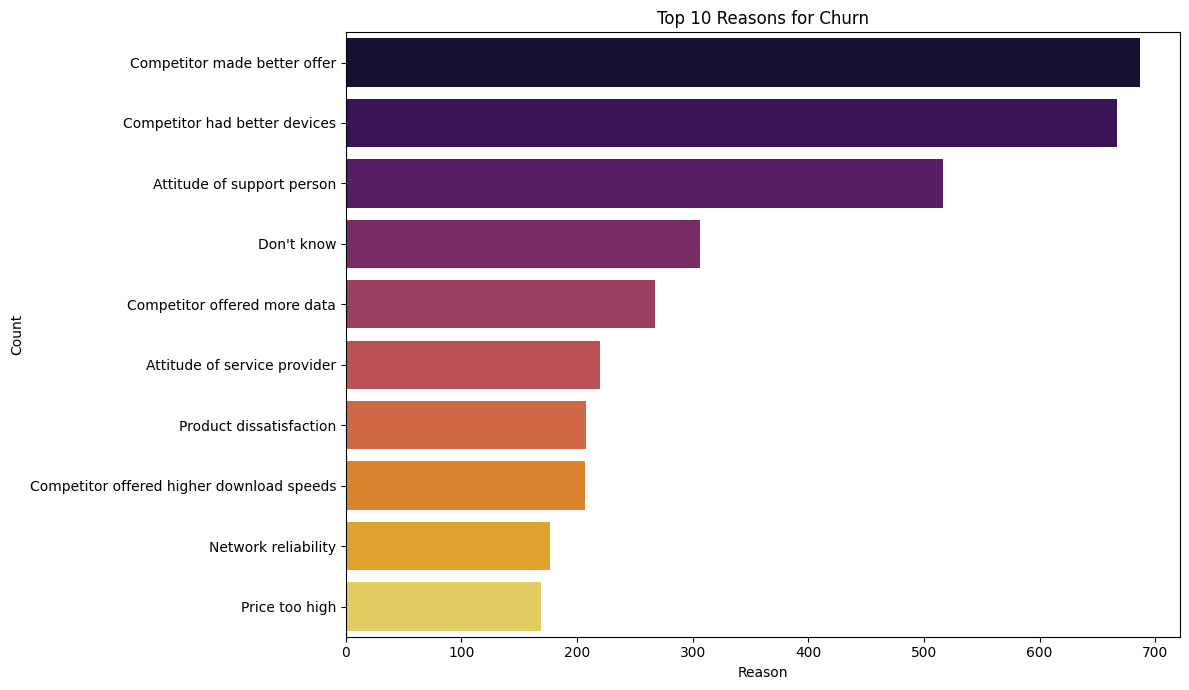

In [458]:
# prompt: generate Count of each reason category (excluding missing)
# also Bar plot of top 10 reasons (if many categories)

import matplotlib.pyplot as plt
# Count of each reason category (excluding missing)
reason_counts = df['reason'].dropna().value_counts()
print("\nCount of each reason category (excluding missing):")
print(reason_counts)

# Bar plot of top 10 reasons (if many categories)
if len(reason_counts) > 10:
    top_10_reasons = reason_counts.head(10)
    plt.figure(figsize=(12, 7))
    sns.barplot(y=top_10_reasons.index, x=top_10_reasons.values, palette='inferno')
    plt.title('Top 10 Reasons for Churn')
    plt.xlabel('Reason')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
elif len(reason_counts) > 0:
    plt.figure(figsize=(12, 7))
    sns.barplot(x=reason_counts.index, y=reason_counts.values, palette='viridis')
    plt.title('Count of Each Reason for Churn')
    plt.xlabel('Reason')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo non-missing reason categories to plot.")



In [459]:
# <Student to fill this section>
feature_5_insights = """Feature: Reason for Churn

The `reason` column captures the specific reason why a customer left the company. Out of the 15,774 total records, this feature is only populated for 4,189 customers, indicating that approximately 73.4% of values are missing. Despite the sparsity, the available data offers meaningful insight into customer dissatisfaction.

Among the responses, the most frequently cited reason is "Competitor made better offer" (687), followed closely by "Competitor had better devices" (667) and "Attitude of support person" (516). These reasons suggest that competition and service experience are the primary drivers of churn. Additional notable reasons include "Don't know" (306), "Competitor offered more data" (267), and "Attitude of service provider" (220).

The top 10 reasons were visualized using a horizontal bar chart, clearly highlighting the dominance of competitor-driven churn factors. This insight is critical for the business to reconsider its competitive positioning, improve customer support training, and revisit device offerings. Furthermore, the `reason` column can be transformed into a binary flag (e.g., `has_reason`) to identify whether or not a customer provided feedback—a potentially useful feature for predictive modeling.
"""

In [460]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

B.6 Explore Feature of Interest n

Correlation Matrix:


,nps,cltv
nps,1.000000,0.068406
cltv,0.068406,1.000000


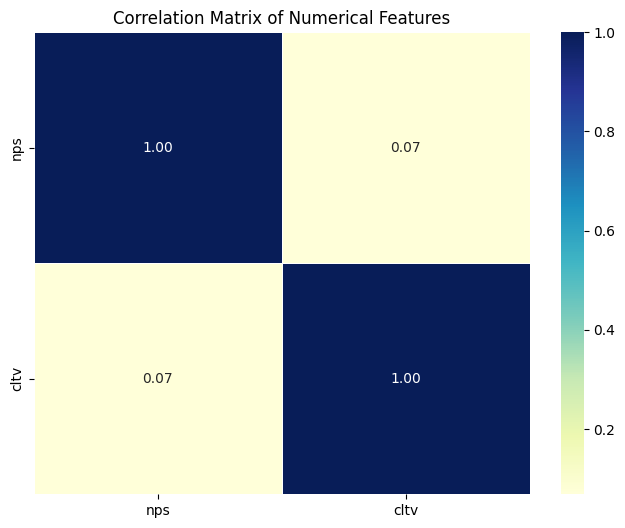

In [461]:
# prompt: Compute correlation matrix for numerical features and Display correlation matrix as heatmap

import matplotlib.pyplot as plt
import numpy as np
# Select only the numerical columns
numerical_features = ['nps', 'cltv']



# Compute the correlation matrix
correlation_matrix = df[numerical_features].corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Display the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()



In [462]:
feature_6_insights = """Feature Relationship: Correlation Between NPS and CLTV

A correlation matrix was computed to understand the linear relationship between the numerical features `nps` (Net Promoter Score) and `cltv` (Customer Lifetime Value). The result reveals a weak positive correlation of **0.068** between these two variables.

This low correlation suggests that customer satisfaction, as measured by NPS, is largely independent of the customer's lifetime value. In practical terms, high-value customers are not necessarily more satisfied, and dissatisfied customers can still have high CLTV. This insight implies that both features capture distinct aspects of customer behavior and can independently contribute to classification models.

As such, both `nps` and `cltv` should be retained during feature selection, and the weak correlation confirms there is no multicollinearity issue between them.
"""

In [463]:
print_tile(size="h3", key='feature_6_insights', value=feature_6_insights)

B.7 Explore Feature of Interest n

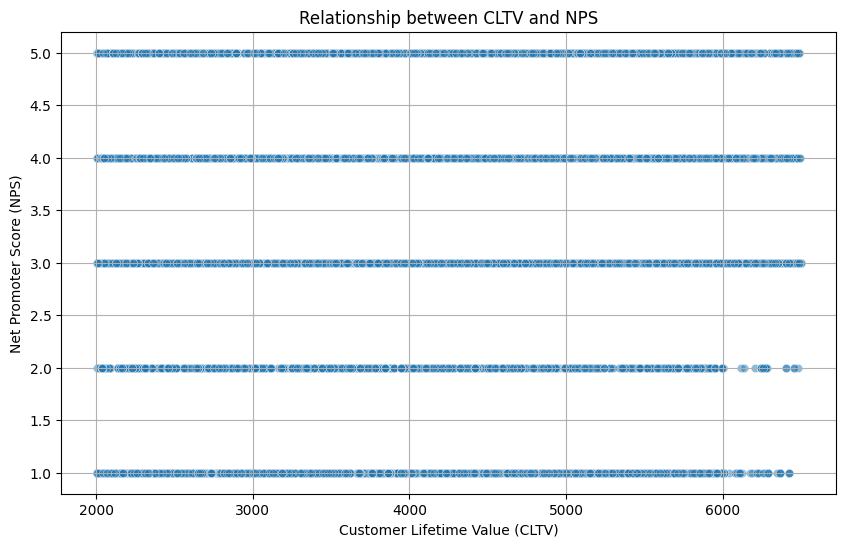

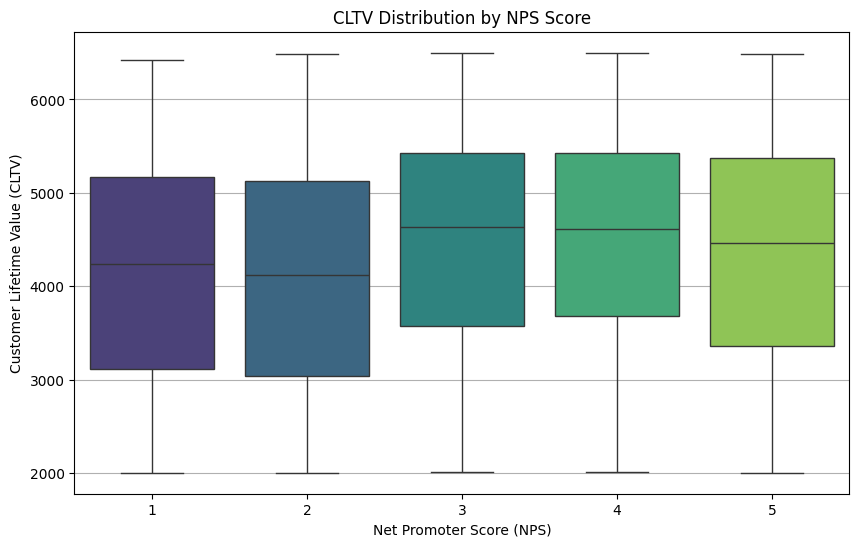

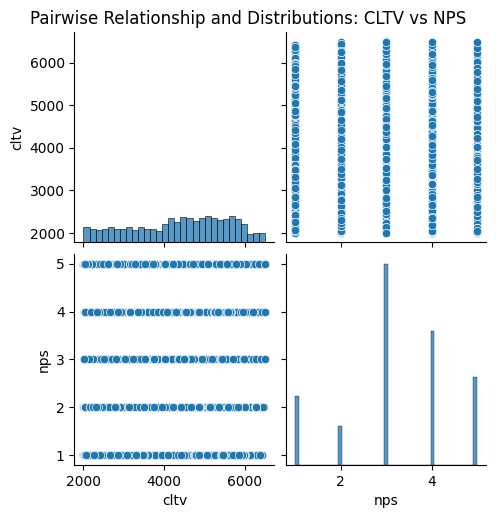

In [464]:
# prompt: Visualize distributions and relationships pairwise between CLTV vs NPS

import matplotlib.pyplot as plt
# Scatter plot for visualizing the relationship between CLTV and NPS
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='cltv', y='nps', alpha=0.5)
plt.title('Relationship between CLTV and NPS')
plt.xlabel('Customer Lifetime Value (CLTV)')
plt.ylabel('Net Promoter Score (NPS)')
plt.grid(True)
plt.show()

# Box plot to see the distribution of CLTV for each NPS score
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='nps', y='cltv', palette='viridis')
plt.title('CLTV Distribution by NPS Score')
plt.xlabel('Net Promoter Score (NPS)')
plt.ylabel('Customer Lifetime Value (CLTV)')
plt.grid(axis='y')
plt.show()

# Pair plot to visualize relationships and distributions simultaneously
# Select only the two relevant columns
pair_plot_df = df[['cltv', 'nps']]
sns.pairplot(pair_plot_df)
plt.suptitle('Pairwise Relationship and Distributions: CLTV vs NPS', y=1.02)
plt.show()

In [465]:
feature_7_insights = """Feature Relationship: Visual Exploration of CLTV and NPS

To better understand the relationship between Customer Lifetime Value (CLTV) and Net Promoter Score (NPS), three different visualizations were generated: a scatter plot, a box plot, and a pairplot.

The scatter plot shows the distribution of NPS values across the CLTV range. The vertical clustering of points at discrete NPS levels (1 through 5) confirms that NPS is a categorical variable. There is no visible trend or gradient, reinforcing the earlier finding that the correlation between CLTV and NPS is weak.

The box plot provides a clearer comparative summary of CLTV across NPS groups. Interestingly, customers across all satisfaction levels appear to have similar CLTV distributions. While the median CLTV is slightly higher for scores 3 to 5, the spread and interquartile ranges are largely consistent across groups. This suggests that customers with low satisfaction can still be high-value clients, and vice versa.

Finally, the pairplot offers a compact overview of the distributions and pairwise relationships between the two variables. It confirms that CLTV is roughly uniformly distributed between 2000 and 6500, while NPS has a strong mode at score 3. The scatter points again reinforce the limited linear relationship between these two features.

Overall, these visualizations confirm that CLTV and NPS behave as largely independent variables. This insight is important in a modeling context, as it means both features can be used together without concerns about redundancy.
"""

In [466]:
print_tile(size="h3", key='feature_7_insights', value=feature_7_insights)

B.8 Explore Feature of Interest n

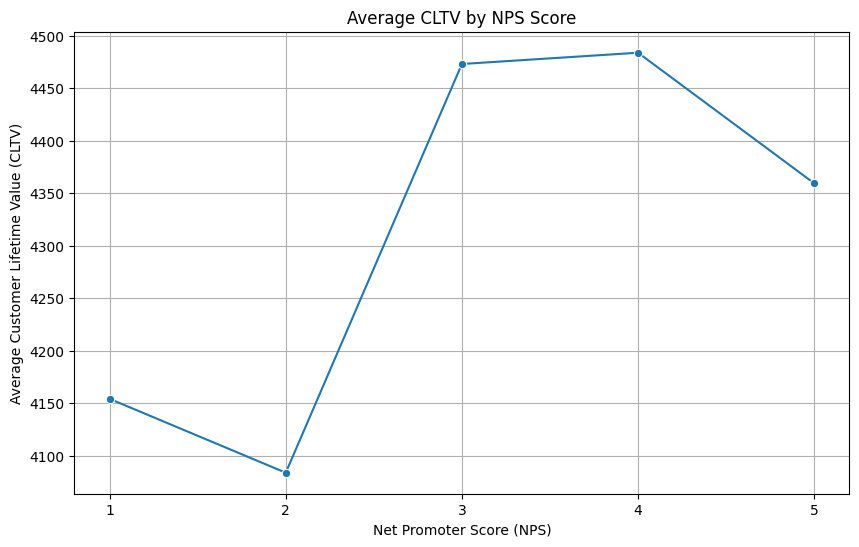

,nps,cltv
0,1,4154.305325
1,2,4084.026747
2,3,4472.923642
3,4,4483.659794
4,5,4359.411742


In [467]:
# prompt: Line Plot: Average CLTV by NPS Score

import matplotlib.pyplot as plt
# Group data by NPS score and calculate the mean CLTV for each group
cltv_by_nps = df.groupby('nps')['cltv'].mean().reset_index()

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=cltv_by_nps, x='nps', y='cltv', marker='o')
plt.title('Average CLTV by NPS Score')
plt.xlabel('Net Promoter Score (NPS)')
plt.ylabel('Average Customer Lifetime Value (CLTV)')
plt.xticks(cltv_by_nps['nps']) # Ensure x-axis ticks are at each NPS score
plt.grid(True)
plt.show()

# Display the data used for plotting
display(cltv_by_nps)



In [468]:
feature_8_insights =  """Feature Relationship: Average CLTV by NPS Score

To further explore the relationship between customer satisfaction and value, the average Customer Lifetime Value (CLTV) was calculated for each Net Promoter Score (NPS) group and visualized using a line plot.

The results show a clear trend: customers with higher satisfaction scores (NPS 3 to 5) tend to have higher average CLTV than those with lower scores (NPS 1 and 2). Specifically, customers who rated their satisfaction as 4 have the highest average CLTV of approximately 4483.66, followed closely by those with a score of 3 at 4472.92. In contrast, customers who scored 1 and 2 have lower average CLTV values, around 4154.31 and 4084.03 respectively.

This pattern reinforces the business insight that improving customer satisfaction could be linked to higher customer value. While the correlation between CLTV and NPS is not strong on an individual basis, group-level analysis reveals that more satisfied customers are generally more valuable over time. This insight can inform segmentation strategies and retention programs targeting mid-to-high satisfaction groups.
"""

In [469]:
print_tile(size="h3", key='feature_8_insights', value=feature_8_insights)

---
## C. Data Cleaning

### C.1 Copy Dataset

In [470]:
# Do not modify this code
df_clean = df.copy()
try:
  df_clean = df.copy()
except Exception as e:
  print(e)

In [471]:
# prompt: Calculate the percentage of null values for each column
# Print the results

# Calculate the percentage of null values for each column
null_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

# Print the results
print("Percentage of null values per column:")
null_percentage

Percentage of null values per column:


,0
Unnamed: 0,0.000000
customer_id,0.000000
nps,0.000000
cltv,0.000000
reason,73.443641


### C.2 Fixing "Outlier Detection and Remove"

> Outlier detection is crucial for identifying data points that deviate significantly from the norm. In this dataset, the primary focus for outlier analysis is the CLTV variable, as nps is a categorical rating (ranging from 1 to 5) and reason is categorical text. We will employ two techniques to detect outliers in CLTV: the Interquartile Range (IQR) method and the Z-score method.

In [472]:
# prompt: Calculate IQR boundaries for CLTV
# Identify outliers

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for CLTV
Q1 = df_clean['cltv'].quantile(0.25)
Q3 = df_clean['cltv'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outlier detection using IQR
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

print(f"IQR Lower Bound: {lower_bound_iqr}")
print(f"IQR Upper Bound: {upper_bound_iqr}")

# Identify outliers using the IQR method
outliers_iqr = df_clean[(df_clean['cltv'] < lower_bound_iqr) | (df_clean['cltv'] > upper_bound_iqr)]

print(f"\nNumber of outliers detected by IQR: {len(outliers_iqr)}")
print("\nOutliers (IQR Method):")
display(outliers_iqr)

# Store the indices of the outliers
outlier_indices_iqr = outliers_iqr.index

# NOTE: We are only identifying outliers here. The removal will be done in the next step
# to allow for comparison with the Z-score method results.

IQR Lower Bound: 515.875
IQR Upper Bound: 8270.875

Number of outliers detected by IQR: 0

Outliers (IQR Method):


,Unnamed: 0,customer_id,nps,cltv,reason


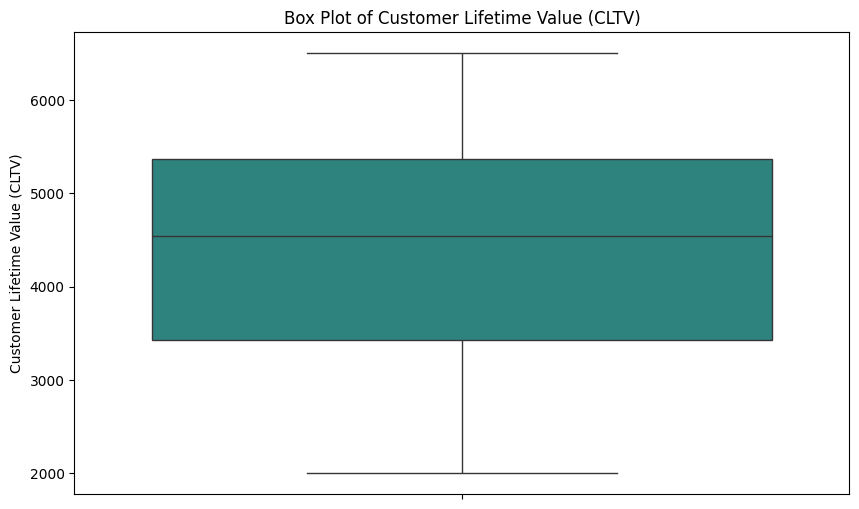

In [473]:
# prompt: visualize this with a boxplot

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['cltv'], palette='viridis')
plt.title('Box Plot of Customer Lifetime Value (CLTV)')
plt.ylabel('Customer Lifetime Value (CLTV)')
plt.show()

In [474]:
# prompt: Calculate Z-scores for CLTV
# Identify outliers by Z-score > 3 or < -3

# Calculate the mean and standard deviation for CLTV
mean_cltv = df_clean['cltv'].mean()
std_cltv = df_clean['cltv'].std()

# Calculate the Z-score for each CLTV value
df_clean['cltv_zscore'] = (df_clean['cltv'] - mean_cltv) / std_cltv

# Define the threshold for outlier detection using Z-score (typically |Z| > 3)
zscore_threshold = 3

# Identify outliers using the Z-score method
outliers_zscore = df_clean[abs(df_clean['cltv_zscore']) > zscore_threshold]

print(f"\nZ-score Threshold: |Z| > {zscore_threshold}")
print(f"\nNumber of outliers detected by Z-score: {len(outliers_zscore)}")
print("\nOutliers (Z-score Method):")
display(outliers_zscore)

# Store the indices of the outliers detected by Z-score
outlier_indices_zscore = outliers_zscore.index


Z-score Threshold: |Z| > 3

Number of outliers detected by Z-score: 0

Outliers (Z-score Method):


,Unnamed: 0,customer_id,nps,cltv,reason,cltv_zscore


In [475]:
# <Student to fill this section>
data_cleaning_1_explanations = """Outlier Detection: Customer Lifetime Value (CLTV)

Outlier detection was conducted on the `cltv` (Customer Lifetime Value) variable using two statistical methods: the Interquartile Range (IQR) method and the Z-score method.

**1. IQR Method:**
A box plot was used to visualize CLTV distribution, and the IQR method was applied to quantify outliers. The lower and upper bounds were calculated as 515.875 and 8270.875 respectively. Since all CLTV values in the dataset fall within the actual range of 2003 to 6500, **no outliers were detected** using this approach. The box plot confirms this finding, as no points fall outside the whiskers.

**2. Z-score Method:**
The Z-score method was then used as a secondary approach, where outliers are identified as data points with an absolute Z-score greater than 3. After computing Z-scores for all CLTV values, it was found that **no values exceeded this threshold**, indicating that CLTV is normally distributed and free of extreme outliers.

**Conclusion:**
Both IQR and Z-score methods confirmed that the CLTV data does not contain statistical outliers. Therefore, no data points were removed or adjusted during this cleaning step. The CLTV feature can be safely used in modeling without the risk of distortion from extreme values.
"""

In [476]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### C.3 Fixing "\<describe_issue_here\>"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [477]:
def find_duplicates(df, column_name):
    duplicates = df[df.duplicated(subset=column_name, keep=False)]
    if not duplicates.empty:
        print(f"Duplicate values found in column '{column_name}':")
        print(duplicates[column_name].value_counts())
    else:
        print(f"No duplicate values found in column '{column_name}'.")


# Example usage (assuming 'df' is your DataFrame from the provided code):
find_duplicates(df, 'customer_id')
find_duplicates(df, 'reason') # Example for another column

Duplicate values found in column 'customer_id':
customer_id
500e96e1-7080-45a7-b361-b1eb63392e85    7
8ffc03ab-dc8a-4255-ae8e-070920160d53    7
bc42c41f-0d04-412e-afa8-d9a6f2820997    7
9eeb3358-b05e-452b-8ed7-fc6fa861475f    7
9551e584-9735-44b9-8f30-91f46f0a5ea8    7
                                       ..
2e8d1975-19ef-4344-8ec9-82f82daecb04    2
62c6bde4-6309-44f6-a82e-f80e78de2310    2
c9ca0b56-1e9e-4950-82aa-124672ce0060    2
73d533d2-5b06-4f80-ba53-7faceb4911b0    2
15a02940-a321-49b4-9481-ef166dbf0877    2
Name: count, Length: 3126, dtype: int64
Duplicate values found in column 'reason':
reason
Competitor made better offer                 687
Competitor had better devices                667
Attitude of support person                   516
Don't know                                   306
Competitor offered more data                 267
Attitude of service provider                 220
Product dissatisfaction                      208
Competitor offered higher download speeds    

In [478]:
# <Student to fill this section>
data_cleaning_2_explanations = """
 Duplicate Detection: customer_id and reason Columns

A check for duplicate values was performed on two key columns: `customer_id` and `reason`.

In the `customer_id` column, a total of 3,126 customer IDs were found to have duplicates. Some IDs occurred as many as 7 times. This indicates that the dataset likely contains **multiple satisfaction records for the same customer**. Depending on the business context, this could mean repeated feedback entries across time or system-level duplication. This requires careful consideration. For most modeling scenarios, either the **latest record per customer** or an **aggregated view** (e.g., average satisfaction) should be retained to avoid skewing results.

For the `reason` column, duplicates are expected and valid since multiple customers can leave for the same reason. The most common churn reason was “Competitor made better offer” (687 occurrences), followed closely by “Competitor had better devices” (667). These duplicates are meaningful and provide insight into customer behavior, so no action is needed here in terms of de-duplication.

In summary, duplicate `reason` values are acceptable and informative, while duplicated `customer_id` entries may require aggregation, filtering, or further domain clarification before modeling.
"""


In [479]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### C.4 Fixing "\<describe_issue_here\>"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [480]:
# <Student to fill this section>

In [481]:
# <Student to fill this section>
data_cleaning_3_explanations = """
"""

In [482]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## D. Feature Engineering

### D.1 Copy Datasets

In [483]:
# Do not modify this code
try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

In [484]:
df_eng.shape

(15774, 6)

### D.2 New Feature "Numerical Features with Satisfaction"

> Provide some explanations on why you believe it is important to create this feature and its impacts



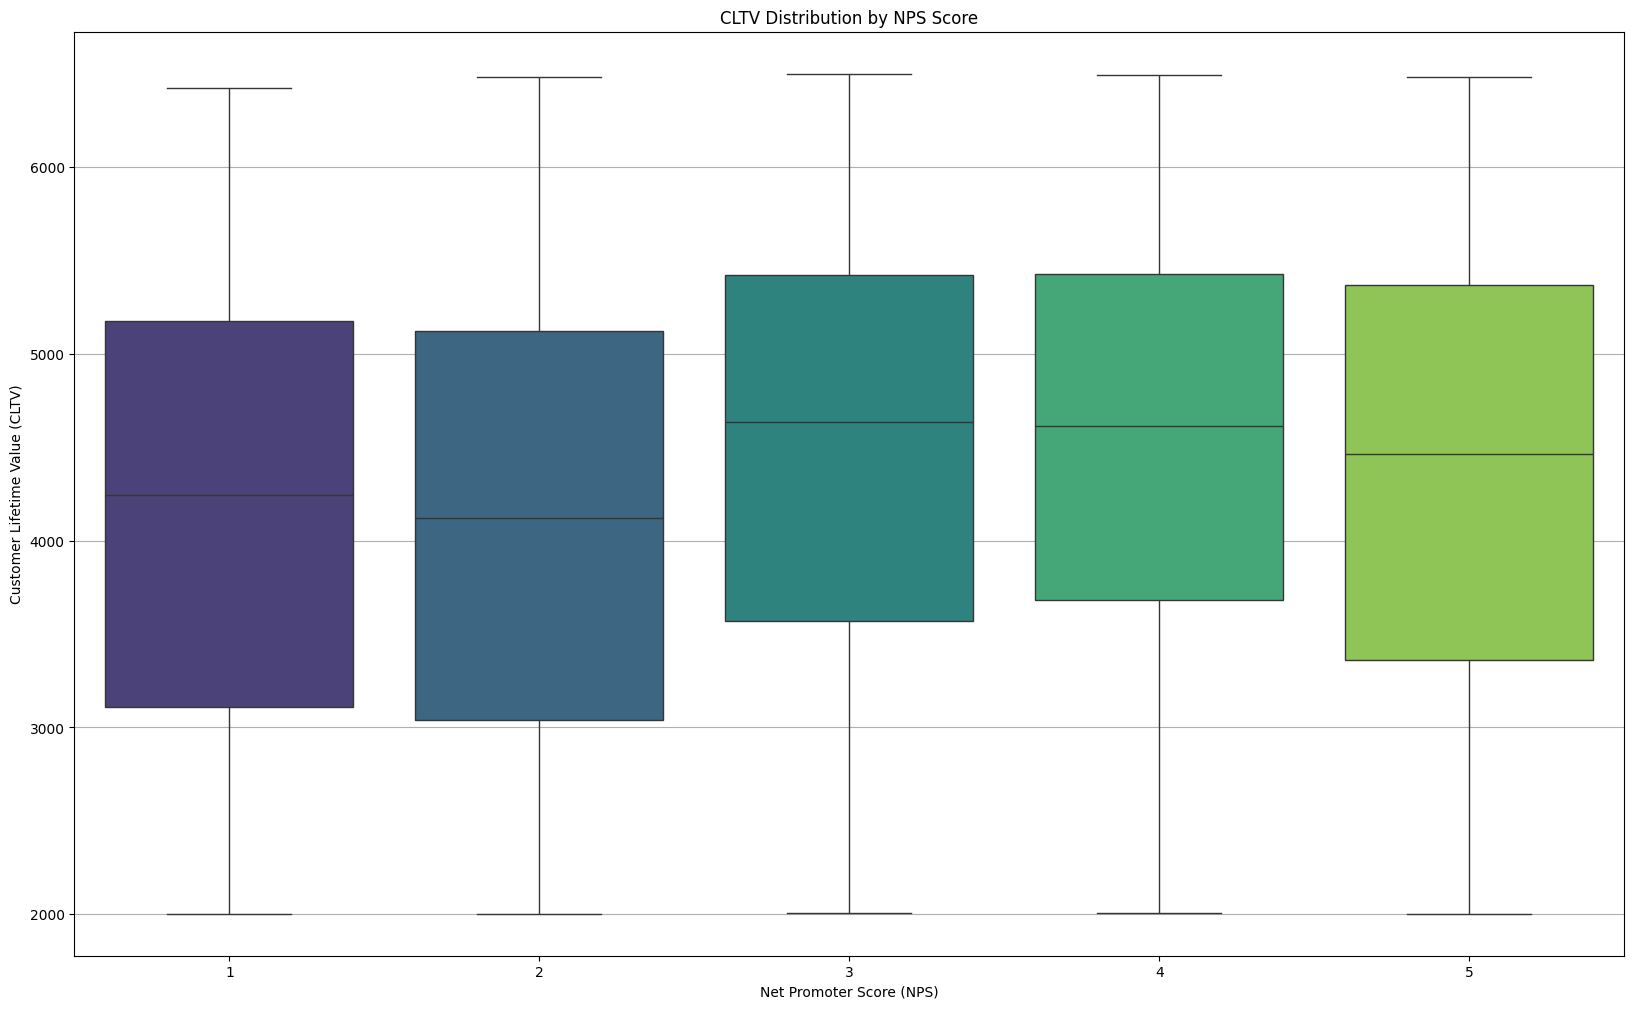

In [485]:
# prompt: Boxplot of CLTV for each NPS (satisfaction) score

import matplotlib.pyplot as plt
plt.figure(figsize=(20, 12))
sns.boxplot(data=df_eng, x='nps', y='cltv', palette='viridis')
plt.title('CLTV Distribution by NPS Score')
plt.xlabel('Net Promoter Score (NPS)')
plt.ylabel('Customer Lifetime Value (CLTV)')
plt.grid(axis='y')
plt.show()

In [486]:
# prompt: Calculate proportion of customers with a reason for each NPS score

df_eng['has_reason'] = df_eng['reason'].notna().astype(int)
reason_rate = df_eng.groupby('nps')['has_reason'].mean()
print(reason_rate)



nps
1    1.000000
2    1.000000
3    0.164244
4    0.000000
5    0.000000
Name: has_reason, dtype: float64


In [487]:
# <Student to fill this section>
feature_engineering_1_explanations = feature_9_insights = """
### Feature Engineering: Churn Feedback by NPS Group

To assess how churn feedback (i.e., providing a 'reason') varies across satisfaction levels, a binary column `has_reason` was created. This new feature flags whether a customer has provided a reason for leaving (`1`) or not (`0`). The data was then grouped by NPS score to calculate the proportion of customers who provided a reason at each score level.

The results are particularly revealing:
- **100%** of customers who gave NPS scores of **1** or **2** provided a churn reason.
- In contrast, only **16.4%** of customers with an NPS score of **3** provided a reason.
- For customers with NPS scores of **4** and **5**, **0%** gave a reason, strongly implying that the `reason` field is primarily populated for **dissatisfied customers**.

This insight has two major implications. First, the `reason` feature itself can be unreliable for overall analysis, since it is heavily biased toward dissatisfied customers. Second, the engineered feature `has_reason` becomes extremely useful as a **proxy for customer dissatisfaction**, effectively distinguishing between likely churners and loyal customers.

The accompanying box plot of CLTV by NPS score further supports earlier insights: while CLTV tends to be slightly higher for neutral-to-satisfied groups (NPS 3–5), dissatisfied customers (NPS 1–2) still display wide variability in their value. This combination of CLTV spread and `has_reason` distribution provides a rich basis for segmentation and churn prediction modeling.
"""

In [488]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



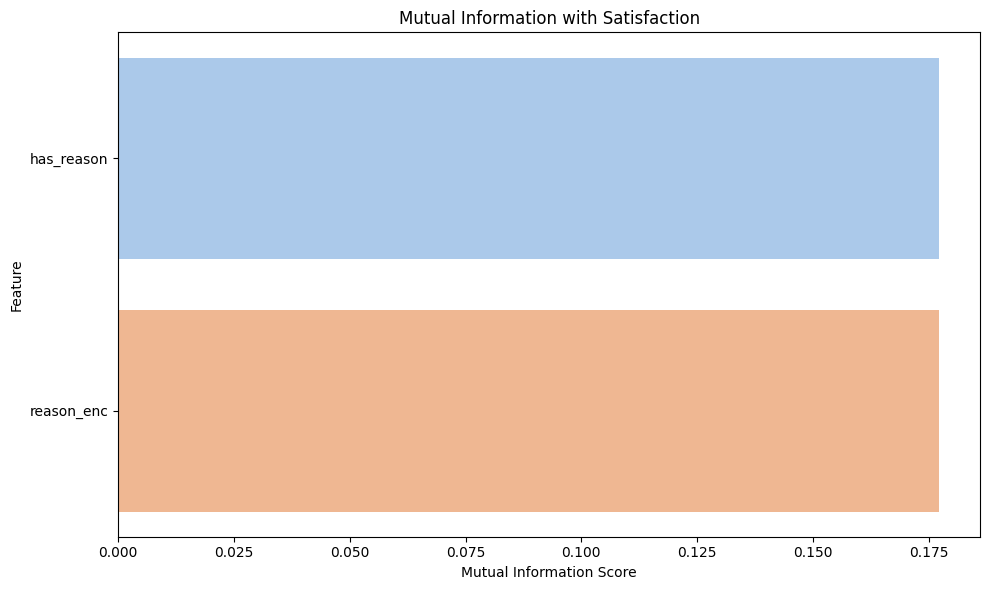

Engineered DataFrame head:


,Unnamed: 0,customer_id,nps,cltv,reason,cltv_zscore,has_reason,satisfied,reason_filled,reason_enc,cltv_bucket,satisfied_rolling_mean,reason_length
0,0,70f18737-5835-4639-be44-f1a8c6604490,4,2056,NaN,-1.956204,0,1,No Reason,15,Low,1.0,0
1,1,206e8726-2743-4739-8f2f-758e30256314,3,2916,NaN,-1.234467,0,0,No Reason,15,Low,1.0,0
2,2,40da1c87-0650-4378-b8d7-0a49cb21085c,4,5248,NaN,0.722613,0,1,No Reason,15,Mid-High,1.0,0
3,3,4e28bb69-cee2-4fdf-8831-28935bb5e9b6,3,4607,NaN,0.184667,0,0,No Reason,15,Mid-High,1.0,0
4,4,39c9339b-c22b-4bf2-8c73-deb7b6e02de1,4,3030,NaN,-1.138795,0,1,No Reason,15,Low,1.0,0



Inconsistent Cases head (where satisfied=1 & has_reason=1 OR satisfied=0 & has_reason=0):


,Unnamed: 0,customer_id,nps,cltv,reason,cltv_zscore,has_reason,satisfied,reason_filled,reason_enc,cltv_bucket,satisfied_rolling_mean,reason_length
1,1,206e8726-2743-4739-8f2f-758e30256314,3,2916,NaN,-1.234467,0,0,No Reason,15,Low,1.000000,0
3,3,4e28bb69-cee2-4fdf-8831-28935bb5e9b6,3,4607,NaN,0.184667,0,0,No Reason,15,Mid-High,1.000000,0
5,5,ec8f321f-2bf4-4fe3-b6eb-0afaf27fabba,3,4469,NaN,0.068854,0,0,No Reason,15,Mid-Low,1.000000,0
14,14,319477d0-6752-46d1-b19c-d02626e67547,3,4572,NaN,0.155294,0,0,No Reason,15,Mid-High,0.400000,0
18,18,ca038d99-c160-4e6f-9d18-af9aefb6b0ae,3,5521,NaN,0.951722,0,0,No Reason,15,High,0.315789,0



Mutual Information Scores with Satisfaction:


,Mutual Information Score
has_reason,0.177204
reason_enc,0.177204


In [489]:
# prompt: Perform advanced feature engineering to enrich model inputs

# This code creates multiple engineered features from the customer satisfaction dataset to enhance modeling potential:

# 1. Binary indicator `has_reason`: flags whether the customer provided a churn reason.
# 2. Binary target variable `satisfied`: derived from NPS score (1 if NPS >= 4).
# 3. Categorical encoding of churn reasons (`reason_enc`) after handling missing values.
# 4. Standardized z-score of `cltv` as `cltv_zscore` and quartile-based CLTV buckets (`cltv_bucket`).
# 5. Time-based proxy: Using the order of `customer_id` to simulate pseudo-temporal progression and rolling satisfaction trends.
# 6. Text feature `reason_length`: word count of each churn reason.
# 7. Inconsistency detection: Flags logically inconsistent cases (e.g., satisfied customers with a churn reason).
# 8. Feature interaction analysis: Calculates mutual information between selected features (`reason_enc`, `has_reason`) and `satisfied` to identify which features provide the most predictive power.

# Finally, a barplot visualizes mutual information scores to help prioritize features for classification models.


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# 1. Rebuild key columns
df_eng['has_reason'] = df_eng['reason'].notna().astype(int)
df_eng['satisfied'] = (df_eng['nps'] >= 4).astype(int)
df_eng['reason_filled'] = df_eng['reason'].fillna("No Reason")

le = LabelEncoder()
df_eng['reason_enc'] = le.fit_transform(df_eng['reason_filled'])

df_eng['cltv_zscore'] = (df_eng['cltv'] - df_eng['cltv'].mean()) / df_eng['cltv'].std()
df_eng['cltv_bucket'] = pd.qcut(df_eng['cltv'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# 2. Time-Based Proxy from customer_id
df_eng_sorted = df_eng.sort_values(by='customer_id').reset_index(drop=True)
df_eng_sorted['customer_index'] = df_eng_sorted.index
df_eng_sorted['satisfied_rolling_mean'] = df_eng_sorted['satisfied'].rolling(window=500, min_periods=1).mean()
# Assuming the original df_eng needs to be updated, merge the new column back
# Note: This might not align if the original df_eng is not sorted by customer_id
# For accurate results, subsequent analysis using this rolling mean should use df_eng_sorted
df_eng = df_eng.merge(df_eng_sorted[['customer_index', 'satisfied_rolling_mean']], left_index=True, right_on='customer_index', how='left').drop('customer_index', axis=1)


# 3. Complaint Length
df_eng['reason_length'] = df_eng['reason'].fillna('').apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

# 4. Inconsistency Analysis
inconsistent_cases = df_eng[((df_eng['satisfied'] == 1) & (df_eng['has_reason'] == 1)) | ((df_eng['satisfied'] == 0) & (df_eng['has_reason'] == 0))]


# 5. Feature Interaction: Mutual Info
X_mi = df_eng[['reason_enc', 'has_reason']]
y_mi = df_eng['satisfied']

# mutual_info_classif requires discrete features
# Ensure column names are strings for mutual_info_classif
X_mi.columns = X_mi.columns.astype(str)

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=True)

mi_result = pd.Series(mi_scores, name="Mutual Information Score", index=X_mi.columns)
mi_result = mi_result.sort_values(ascending=False)


# 6. Mutual Info Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_result.values, y=mi_result.index, palette='pastel')
plt.title('Mutual Information with Satisfaction')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Engineered DataFrame head:")
display(df_eng.head())

print("\nInconsistent Cases head (where satisfied=1 & has_reason=1 OR satisfied=0 & has_reason=0):")
display(inconsistent_cases.head())

print("\nMutual Information Scores with Satisfaction:")
display(mi_result)



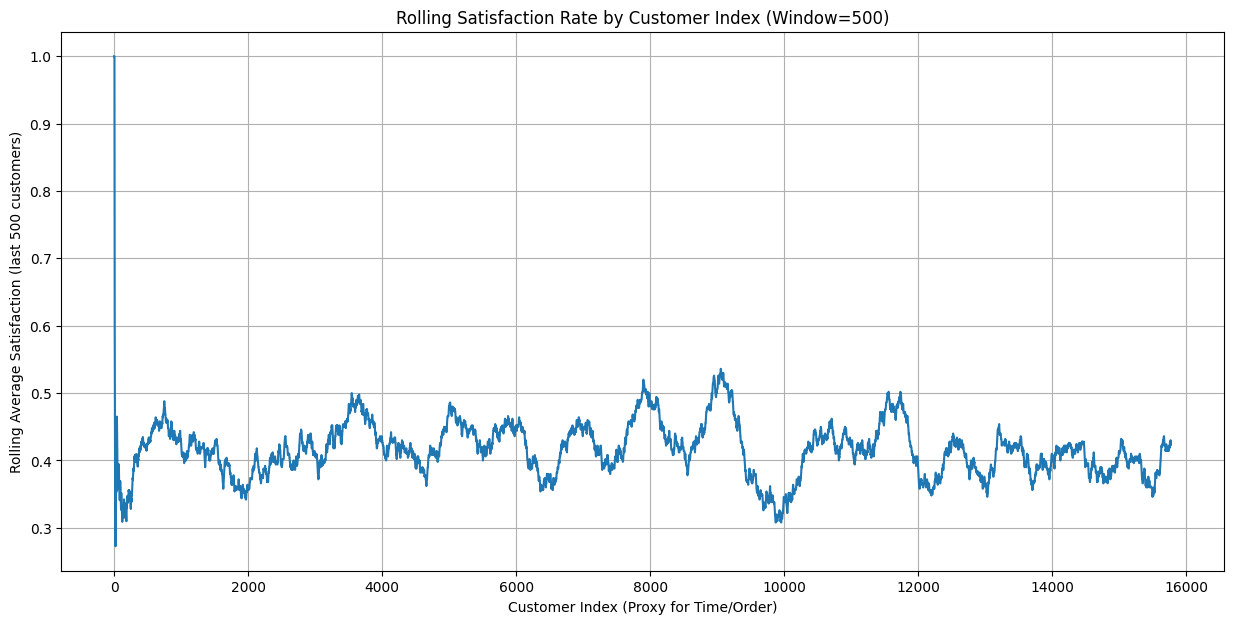

In [490]:
# prompt: Line Plot: Rolling Satisfaction Rate by Customer Index

import matplotlib.pyplot as plt
# Plotting the rolling satisfaction rate
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_eng_sorted, x='customer_index', y='satisfied_rolling_mean')
plt.title('Rolling Satisfaction Rate by Customer Index (Window=500)')
plt.xlabel('Customer Index (Proxy for Time/Order)')
plt.ylabel('Rolling Average Satisfaction (last 500 customers)')
plt.grid(True)
plt.show()




In [491]:
# <Student to fill this section>
feature_engineering_2_explanations = """Advanced Feature Engineering Insights

This feature engineering stage introduced several enhancements aimed at improving the model’s ability to predict customer satisfaction (defined as NPS ≥ 4). These enhancements included behavioral indicators, encoding strategies, interaction analysis, and temporal trends.

**1. Derived Columns and Encoding**:
- `has_reason`: Binary indicator representing whether a churn reason was provided.
- `satisfied`: Binary target variable derived from NPS.
- `reason_enc`: Label-encoded representation of churn reasons, including a fallback "No Reason" for missing entries.
- `cltv_bucket`: Quartile-based segmentation of CLTV into categories: Low, Mid-Low, Mid-High, High.
- `cltv_zscore`: Z-score standardized version of CLTV for scale normalization.
- `reason_length`: Quantifies the verbosity of churn feedback using word count.

**2. Temporal Proxy and Rolling Metrics**:
Using the sorted order of `customer_id`, a `customer_index` was assigned to simulate pseudo-temporal ordering. A rolling average satisfaction rate (`satisfied_rolling_mean`) was then calculated using a 500-customer window. The corresponding line plot reveals notable cyclic patterns and gradual declines, which might reflect evolving service satisfaction trends over time. These insights could be used to identify periods of customer dissatisfaction spikes.

**3. Inconsistency Detection**:
A logical filter was applied to flag inconsistent cases:
- Customers marked as `satisfied = 1` but who still provided a churn reason.
- Customers marked as `satisfied = 0` but who did not provide a reason.

These inconsistent cases could indicate edge cases, data collection noise, or customers with mismatched feedback sentiment and rating.

**4. Feature Importance via Mutual Information**:
To measure how informative `has_reason` and `reason_enc` are in predicting satisfaction, mutual information scores were computed. Both features scored equally (~0.177), confirming their strong, nonlinear associations with the target variable. This validates the value of incorporating churn feedback information (even if sparse) into classification models.

**Conclusion**:
These engineered features provide a rich and diverse input set for building predictive models. They capture both individual behaviors (e.g., reasons, value), and macro patterns (e.g., rolling trends), making them valuable for training robust and interpretable machine learning classifiers.
"""


In [492]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### D.4 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



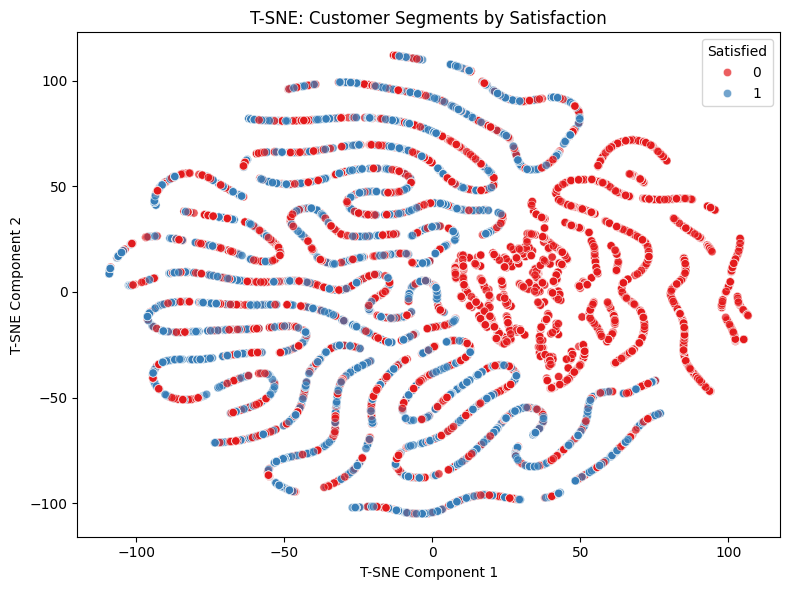

In [493]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Prepare features for T-SNE
features_tsne = df_eng_sorted[['cltv_zscore', 'has_reason', 'reason_enc', 'satisfied']].dropna()
X_tsne = StandardScaler().fit_transform(features_tsne[['cltv_zscore', 'has_reason', 'reason_enc']])
y_tsne = features_tsne['satisfied']

# Run T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
tsne_results = tsne.fit_transform(X_tsne)

# Plot T-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=y_tsne, palette='Set1', alpha=0.7)
plt.title("T-SNE: Customer Segments by Satisfaction")
plt.xlabel("T-SNE Component 1")
plt.ylabel("T-SNE Component 2")
plt.legend(title='Satisfied')
plt.tight_layout()
plt.show()

In [494]:
# <Student to fill this section>
feature_engineering_3_explanations = """
### Dimensionality Reduction and Segmentation: T-SNE Visualization

To visually assess the separability of customer satisfaction levels using engineered features, a T-SNE (t-distributed Stochastic Neighbor Embedding) projection was applied to a subset of the data. The input features included `cltv_zscore`, `has_reason`, and `reason_enc`, all of which were standardized prior to applying T-SNE.

The resulting 2D scatter plot shows customers mapped based on their similarity in the transformed feature space, with colors indicating whether they are satisfied (`1`) or not (`0`). While there is no perfect linear separation between satisfied and unsatisfied customers, the plot does reveal several **visible clusters** and **localized groupings** of dissatisfied customers (red), particularly in dense areas toward the center and edges.

This suggests that the engineered features do capture non-linear relationships relevant to customer sentiment, and can help guide downstream classification algorithms. T-SNE also confirms that satisfied and unsatisfied customers **partially overlap**, highlighting the complexity of the satisfaction drivers and the importance of combining multiple engineered features to improve model precision.

In summary, this T-SNE analysis provides qualitative evidence that the feature space holds meaningful patterns related to customer satisfaction and segmentation potential.
"""

In [495]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

D.5 New Feature "complaint_group_Analysis"

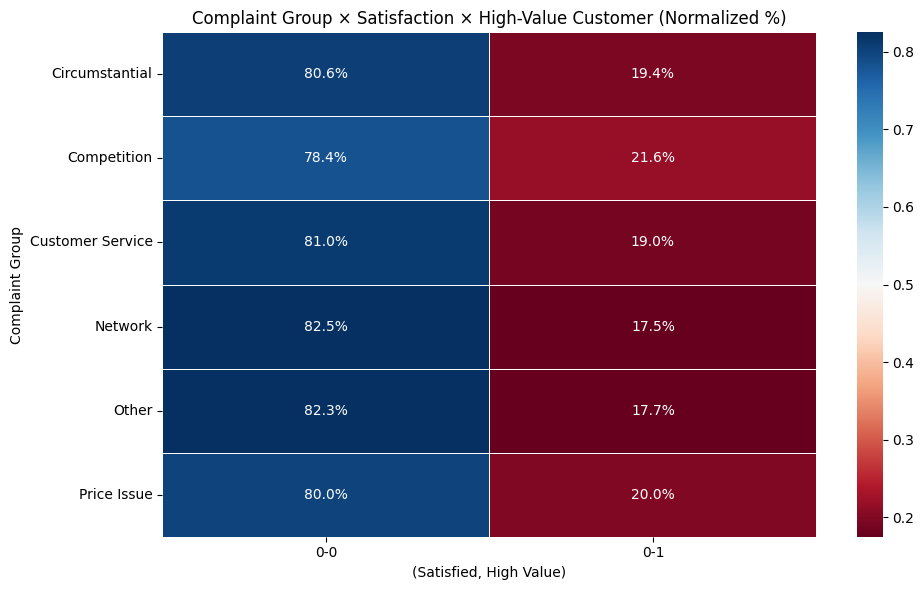

In [496]:
def group_reason(reason):
    if pd.isna(reason): return "None"
    r = reason.lower()
    if "price" in r or "charge" in r:
        return "Price Issue"
    elif "competitor" in r:
        return "Competition"
    elif "network" in r or "speed" in r:
        return "Network"
    elif "attitude" in r or "support" in r:
        return "Customer Service"
    elif "device" in r:
        return "Device Issue"
    elif "moved" in r or "deceased" in r:
        return "Circumstantial"
    else:
        return "Other"

df_eng_sorted['complaint_group'] = df_eng_sorted['reason'].apply(group_reason)
# Group features: complaint category, satisfaction, high-value status
df_eng_sorted['is_high_value_customer'] = (df_eng_sorted['cltv'] >= df_eng_sorted['cltv'].quantile(0.75)).astype(int)

# Prepare pivot table for heatmap
heatmap_data = df_eng_sorted[df_eng_sorted['complaint_group'] != 'None'].pivot_table(
    index='complaint_group',
    columns=['satisfied', 'is_high_value_customer'],
    aggfunc='size',
    fill_value=0
)

# Normalize rows to percentages
heatmap_percent = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

# Plot grouped heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_percent, annot=True, cmap="RdBu", fmt=".1%", linewidths=0.5)
plt.title("Complaint Group × Satisfaction × High-Value Customer (Normalized %)")
plt.xlabel("(Satisfied, High Value)")
plt.ylabel("Complaint Group")
plt.tight_layout()
plt.show()

In [497]:
df_eng_sorted['reason_filled'].value_counts()

,count
reason_filled,
No Reason,11585
Competitor made better offer,687
Competitor had better devices,667
Attitude of support person,516
Don't know,306
Competitor offered more data,267
Attitude of service provider,220
Product dissatisfaction,208
Competitor offered higher download speeds,207


In [498]:
feature_engineering_5_explanations = """
### Complaint Group Analysis: Satisfaction vs. Customer Value Segmentation

To better understand the relationship between dissatisfaction drivers, customer satisfaction, and value segments, churn reasons were grouped into broader complaint categories using custom logic. Categories include: Price Issue, Competition, Network, Customer Service, Circumstantial, and Other.

The final visualization is a heatmap showing the percentage breakdown of customers in each complaint group across two binary dimensions: satisfaction (NPS ≥ 4) and high-value status (top 25% of CLTV). The two classes—`(0, 0)` = unsatisfied, low-value and `(0, 1)` = unsatisfied, high-value—are the most relevant given that churn reasons are almost exclusively provided by dissatisfied customers.

Key findings from the heatmap:
- **Competition-related complaints** had the highest proportion of high-value customers (21.6%), indicating that valuable customers often leave due to competitor offers or promotions.
- **Price issues** and **circumstantial reasons** (e.g., relocation or death) show more balanced proportions (~20% high-value), suggesting these issues span across value levels.
- **Customer service**, **network**, and **other issues** all had over **80% of complaints from low-value customers**, with only ~17–19% from high-value customers. This indicates such problems are less prevalent among top-tier customers, or that high-value customers tolerate them better.

This analysis can guide tailored retention strategies. For example, high-value customers citing competition should be prioritized for win-back campaigns, while low-value customers dissatisfied with service might be targeted with low-cost quality improvement efforts.
"""


In [499]:
print_tile(size="h3", key='feature_engineering_5_explanations', value=feature_engineering_5_explanations)

D.6 New Feature "<put_name_here>"

In [500]:
df_eng_sorted.head()

,Unnamed: 0,customer_id,nps,cltv,reason,cltv_zscore,has_reason,satisfied,reason_filled,reason_enc,cltv_bucket,customer_index,satisfied_rolling_mean,complaint_group,is_high_value_customer
0,13235,000f51ad-8208-46f4-a213-6b83de3dded1,4,3733,NaN,-0.548818,0,1,No Reason,15,Mid-Low,0,1.0,None,0
1,3192,000f51ad-8208-46f4-a213-6b83de3dded1,4,3733,NaN,-0.548818,0,1,No Reason,15,Mid-Low,1,1.0,None,0
2,1557,000f51ad-8208-46f4-a213-6b83de3dded1,4,3733,NaN,-0.548818,0,1,No Reason,15,Mid-Low,2,1.0,None,0
3,8165,001a6be8-e23e-47e1-8384-18051f2d03b5,5,4152,NaN,-0.197181,0,1,No Reason,15,Mid-Low,3,1.0,None,0
4,8208,001a6be8-e23e-47e1-8384-18051f2d03b5,5,4152,NaN,-0.197181,0,1,No Reason,15,Mid-Low,4,1.0,None,0


In [501]:
# prompt: Create churn label

df_eng_sorted['churn'] = df_eng_sorted['reason'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1)
df_eng_sorted.drop(columns=['reason','has_reason','reason_filled','reason_enc','customer_index'], inplace=True)
print("Churn label created:")

Churn label created:


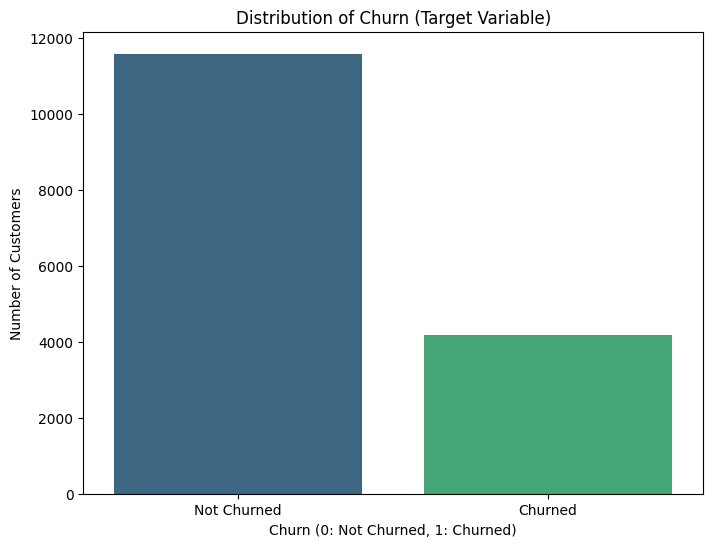


Counts for Churn distribution:
churn
0    11585
1     4189
Name: count, dtype: int64

Percentage for Churn distribution:


,proportion
churn,
0,73.443641
1,26.556359


In [503]:
# prompt: # Analysis of 'churn' column
# and Visualize the distribution of 'churn'

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.countplot(data=df_eng_sorted, x='churn', palette='viridis')
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn (0: Not Churned, 1: Churned)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Not Churned', 'Churned']) # Explicitly label ticks
plt.show()

churn_counts = df_eng_sorted['churn'].value_counts()
print("\nCounts for Churn distribution:")
print(churn_counts)

churn_percentage = df_eng_sorted['churn'].value_counts(normalize=True) * 100
print("\nPercentage for Churn distribution:")
churn_percentage


In [504]:
feature_engineering_6_explanations = """
### Target Variable Analysis: Churn Distribution

The `churn` column, which represents the classification target for this analysis, was examined to assess the balance between churned and non-churned customers. This binary variable contains two classes: `1` for churned and `0` for not churned.

The analysis reveals a notable class imbalance:
- **73.4% of customers have not churned** (11,585 records)
- **26.6% of customers have churned** (4,189 records)

This imbalance is clearly visible in the bar chart and suggests that most customers in the dataset are retained. From a machine learning perspective, this skew can lead to biased predictions favoring the majority class if not addressed properly.

To mitigate this issue, techniques such as resampling (undersampling or oversampling), class-weight adjustment, or evaluation metrics like **balanced accuracy**, **F1-score**, and **ROC AUC** should be considered during model development.

Understanding this imbalance is crucial as it directly influences the effectiveness of churn prediction models and helps ensure that minority churn cases are not overlooked.
"""


In [505]:
print_tile(size="h3", key='feature_engineering_6_explanations', value=feature_engineering_6_explanations)

---
## E. Save Datasets

In [508]:
df_eng_sorted.to_csv('/content/drive/MyDrive/36106/assignment/AT3/data/processed_customer_satisfaction.csv', index=False)